In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from unidecode import unidecode
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Lendo e analisando df Geral

In [4]:
dados = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx')

In [5]:
dados.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.488497,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.811504,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.152090,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.672943,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.760782,NaN


In [6]:
dados.columns = [col.strip().replace("_", " ") for col in dados.columns]

In [7]:
print(dados.columns)


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')


In [8]:
dados_long = dados.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

In [ ]:
dados_long["Year"] = dados_long["Year"].astype(int)

In [100]:
# Lista completa de indicadores categorizados
indicadores = {
    # Demográficos
    "demograficos": [    
        "Fertility rate, total (births per woman)",
        "Mortality rate, infant (per 1.000 live births)",
        "Life expectancy at birth, total (years)",
        "Net migration",
        "Birth rate, crude (per 1.000 people)",
        "Population growth (annual %)",
        "Population ages 0-14 (% of total population)",
        "Population ages 15-64 (% of total population)",
        "Population ages 65 and above (% of total population)",
        "Population, total",
    ],
    
    # Econômicos
    "economicos": [
        "GDP per capita (current US$)",
        "GDP growth (annual %)",
        "Unemployment, total (% of total labor force)",
        "Domestic credit to private sector (% of GDP)",
        "GDP (current US$)",
        "Gross domestic savings (% of GDP)",
        "Labor force, total",   
        "Labor force participation rate, total (% of total population ages 15+)",
    ],
    
    # Urbanização
    "urbanizacao": [
        "Urban population (% of total population)",
        "Urban population growth (annual %)",
        "Population in largest city",
        "Urban land area (% of total land area)",
        "Population density (people per sq. km of land area)",
        "Rural population (% of total population)",
        "Rural population growth (annual %)",
        "Population living in slums (% of urban population)",
        "Population in largest city (% of urban population)",
        "Population in cities with 1 million inhabitants (% of total population)",
    ],
    
    # Educação
    "educacao": [
        "School enrollment, primary (% net)",
        "Literacy rate, adult total (% of people ages 15 and above)",
        "School enrollment, secondary (% net)",
        "School enrollment, tertiary (% gross)",
        "Pupil-teacher ratio, primary",
        "Pupil-teacher ratio, secondary",
        "Pupil-teacher ratio, tertiary",
        "Education expenditure, total (% of GDP)",
        "Education expenditure, total (% of government expenditure)",
    ],
    
    # Saúde
    "saude": [
        "Health expenditure, total (% of GDP)",
        "Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)",
        "Mortality rate, under-5 (per 1,000 live births)",
        "Prevalence of HIV, total (% of population ages 15-49)",
        "People using at least basic sanitation services (% of population)",
        "Access to electricity (% of population)",
    ],
    
    # Pobreza e desigualdade
    "pobreza": [
        "Gini index",
        "Income share held by highest 10%",
        "Income share held by lowest 10%",
    ]
}

# Criar dicionário de DataFrames filtrados
dados_categorizados = {
    categoria: dados_long[dados_long["Indicator Name"].isin(indicadores)]
    for categoria, indicadores in indicadores.items()
}

# DataFrame com todos os indicadores de interesse (equivalente ao dados_filtrados original)
dados_filtrados = dados_long[dados_long["Indicator Name"].isin(
    [item for sublist in indicadores.values() for item in sublist]
)]


In [102]:
# Processamento por país (mantendo sua estrutura original)
paises_unicos = dados_filtrados["Country Name"].unique()

sub_dfs_por_pais = {
    pais: grupo.drop(columns=["Country Code", "Country Name"]).reset_index(drop=True)
    for pais, grupo in dados_filtrados.groupby("Country Name")
}

# Exemplo para o Brasil
brasil = sub_dfs_por_pais["Brazil"]
print("\nDados do Brasil:")
print(brasil.head())


Dados do Brasil:
                                 Indicator Name     Indicator Code  Year  \
0       Access to electricity (% of population)     EG.ELC.ACCS.ZS  1960   
1  Domestic credit to private sector (% of GDP)  FS.AST.PRVT.GD.ZS  1960   
2      Fertility rate, total (births per woman)     SP.DYN.TFRT.IN  1960   
3                             GDP (current US$)     NY.GDP.MKTP.CD  1960   
4                         GDP growth (annual %)  NY.GDP.MKTP.KD.ZG  1960   

          Value  
0           NaN  
1  1.797273e+01  
2  6.061000e+00  
3  1.703047e+10  
4           NaN  


## Analise do Brasil

### Explorando o DF

In [135]:
# Pré-processamento corrigido
brasil = sub_dfs_por_pais["Brazil"]

# Verificar e converter o ano para datetime
brasil['Year'] = pd.to_datetime(brasil['Year'], format='%Y')

# Criar DataFrame wide com índice temporal
df_brasil_wide = brasil.pivot(index='Year', columns='Indicator Name', values='Value')

# Ordenar por data
df_brasil_wide = df_brasil_wide.sort_index()

# Preenchimento de valores ausentes corrigido
dados_brasil_filled = df_brasil_wide.interpolate(method='time').ffill().bfill()




In [136]:
if 'Population growth (annual %)' in dados_brasil_filled.columns:
    crescimento = dados_brasil_filled['Population growth (annual %)'].dropna()
    
    fig = px.line(crescimento, 
                 title='<b>Evolução da Taxa de Crescimento Populacional no Brasil</b>',
                 labels={'value': 'Taxa de Crescimento (%)', 'Year': 'Ano'})
    
    # Adicionar média móvel
    crescimento_ma = crescimento.rolling(5, min_periods=1).mean()
    fig.add_trace(go.Scatter(x=crescimento_ma.index, y=crescimento_ma,
                           name='Média Móvel (5 anos)',
                           line=dict(color='red', dash='dot')))
    
    fig.update_layout(template='plotly_white', height=500)
    fig.show()
else:
    print("Variável 'Population growth (annual %)' não encontrada nos dados")


In [158]:
# Versão unificada e consistente:

def analise_correlacao_consistente(df, variaveis):
    """
    Função para análise de correlação consistente
    """
    # Verificar variáveis disponíveis
    vars_disponiveis = [var for var in variaveis if var in df.columns]
    
    if len(vars_disponiveis) < 2:
        print(f"Não há variáveis suficientes. Disponíveis: {vars_disponiveis}")
        return None
    
    # Calcular matriz de correlação
    corr_matrix = df[vars_disponiveis].corr()
    
    # Plotar com Plotly (interativo)
    fig = go.Figure(data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns,
        y=corr_matrix.index,
        colorscale='RdBu',
        zmin=-1,
        zmax=1,
        text=np.round(corr_matrix.values, 2),
        texttemplate="%{text}"))
    
    fig.update_layout(
        title='<b>Matriz de Correlação Consistente</b>',
        height=600,
        xaxis_title="Variáveis",
        yaxis_title="Variáveis",
        template='plotly_white'
    )
    fig.show()
    
    return corr_matrix

# Variáveis para análise (lista unificada)
variaveis_correlacao = [
    'Population growth (annual %)',
    'Fertility rate, total (births per woman)',
    'Life expectancy at birth, total (years)',
    'Urban population (% of total population)',
    'GDP per capita (current US$)',
    'Gini index',
    'Population, total',
    'Labor force, total'
]

# Usar dados_brasil_filled que já está tratado
correlacao_final = analise_correlacao_consistente(dados_brasil_filled, variaveis_correlacao)

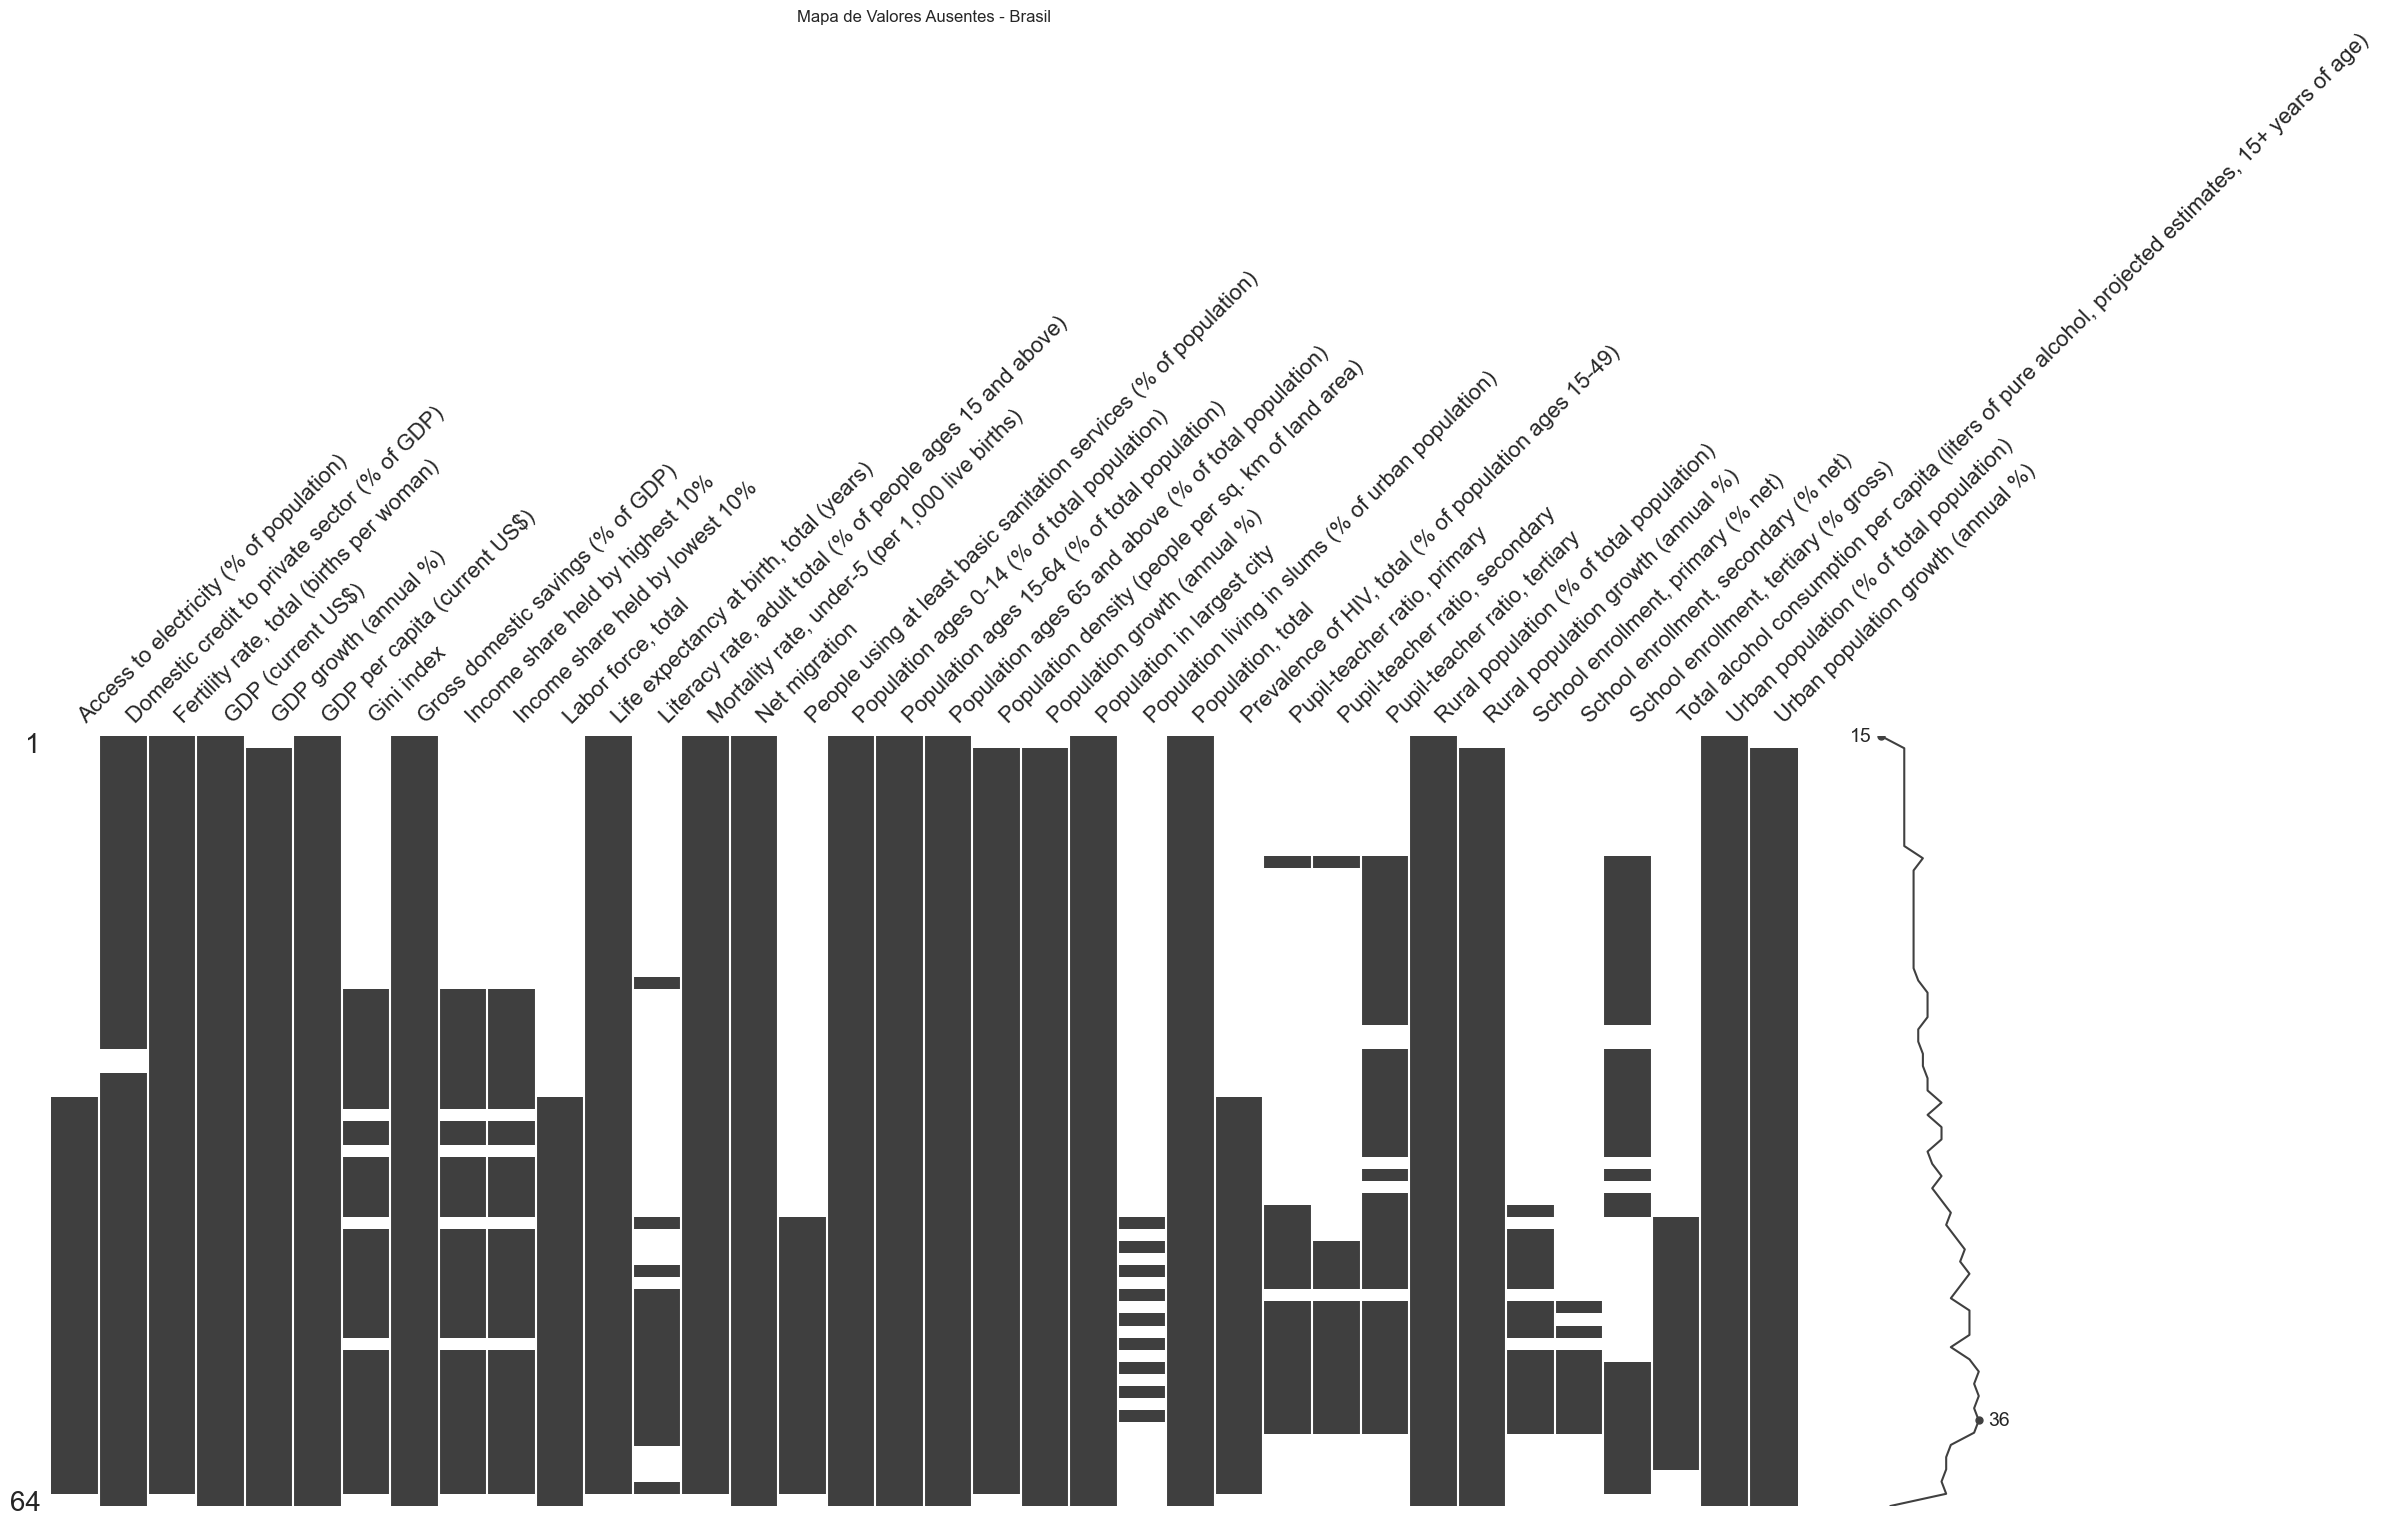

In [139]:
import missingno as msno
msno.matrix(df_brasil_wide)
plt.title('Mapa de Valores Ausentes - Brasil')
plt.show()

In [141]:
import plotly.express as px

# Preparar os dados
df_plot = corr_target.reset_index()
df_plot.columns = ['Variável', 'Correlação']
df_plot['Correlação'] = df_plot['Correlação'].round(3)
df_plot['Cor_abs'] = df_plot['Correlação'].abs()
df_plot['Tipo'] = df_plot['Correlação'].apply(lambda x: 'Positiva' if x > 0 else 'Negativa')

# Criar gráfico
fig = px.bar(df_plot, 
             x='Correlação', 
             y='Variável',
             color='Correlação',
             color_continuous_scale='RdBu',
             range_color=[-1, 1],
             title='<b>Correlação com Crescimento Populacional (Brasil)</b>',
             text='Correlação',
             hover_data={'Cor_abs': False, 'Tipo': True},
             height=600)

# Ajustes estéticos
fig.update_traces(texttemplate='%{text:.2f}', 
                 textposition='outside',
                 marker_line_color='black',
                 marker_line_width=0.5)
fig.update_layout(plot_bgcolor='white',
                 xaxis_range=[-1.1,1.1],
                 xaxis_title='Coeficiente de Correlação',
                 yaxis_title='Variáveis',
                 coloraxis_colorbar_title='Correlação')
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="grey")

fig.show()

In [142]:


# Filtrar os dados
crescimento_pop = brasil[brasil['Indicator Name'] == 'Population growth (annual %)']
pop_brasil = brasil[brasil['Indicator Name'] == 'Population, total']

# Criar figura com eixo secundário
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Adiciona o trace de crescimento populacional (eixo Y primário)
fig.add_trace(
    go.Scatter(
        x=crescimento_pop['Year'],
        y=crescimento_pop['Value'],
        mode='lines+markers',
        name='Crescimento Anual (%)',
        line=dict(color='blue')
    ),
    secondary_y=False,
)

# Adiciona o trace de população total (eixo Y secundário)
fig.add_trace(
    go.Scatter(
        x=pop_brasil['Year'],
        y=pop_brasil['Value'],
        mode='lines+markers',
        name='População Total',
        line=dict(color='orange')
    ),
    secondary_y=True,
)

# Atualiza o layout e os títulos dos eixos
fig.update_layout(
    title_text="População Total e Crescimento Populacional do Brasil",
    xaxis_title="Ano",
    template='plotly_white',
    hovermode='x unified'
)
fig.update_yaxes(title_text="Crescimento Anual (%)", secondary_y=False)
fig.update_yaxes(title_text="População Total", secondary_y=True)

fig.show()



<Figure size 1200x600 with 0 Axes>

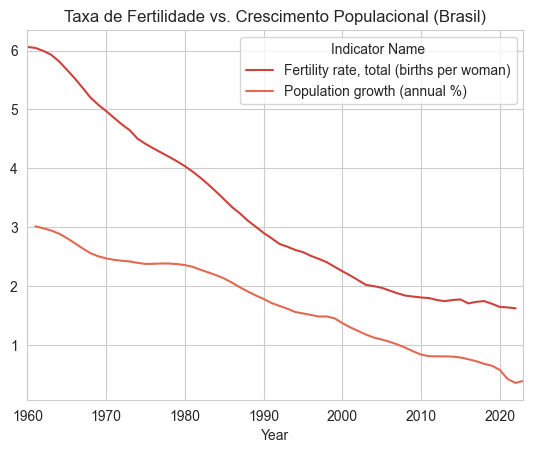

In [143]:
import matplotlib.pyplot as plt

# Exemplo: Fertility rate vs. Population growth
plt.figure(figsize=(12, 6))
df_brasil_wide[["Fertility rate, total (births per woman)", "Population growth (annual %)"]].plot()
plt.title("Taxa de Fertilidade vs. Crescimento Populacional (Brasil)")
plt.show()

In [144]:
# Análise de fatores demográficos que afetam a população
fatores_demograficos = [
    'Fertility rate, total (births per woman)',
    'Mortality rate, infant (per 1.000 live births)',
    'Life expectancy at birth, total (years)',
    'Birth rate, crude (per 1.000 people)'
]

# Normalizando os dados para visualização conjunta
dados_demograficos = brasil[brasil['Indicator Name'].isin(fatores_demograficos)].copy()

# Pivot para ter cada indicador como coluna
dados_pivot = dados_demograficos.pivot(index='Year', columns='Indicator Name', values='Value')

# Normalização min-max para cada coluna
dados_norm = (dados_pivot - dados_pivot.min()) / (dados_pivot.max() - dados_pivot.min())


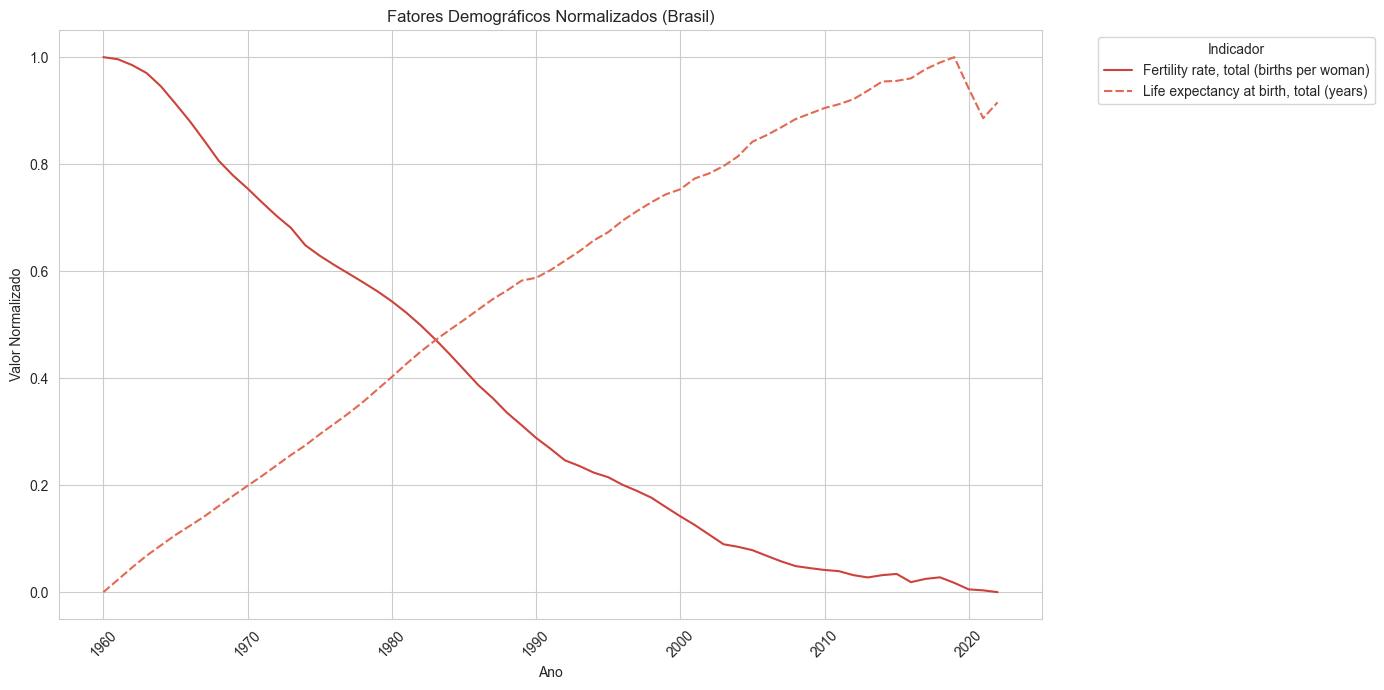

In [145]:
# Plotando dados normalizados
plt.figure(figsize=(14, 7))
sns.lineplot(data=dados_norm)
plt.title('Fatores Demográficos Normalizados (Brasil)')
plt.ylabel('Valor Normalizado')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Indicador', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

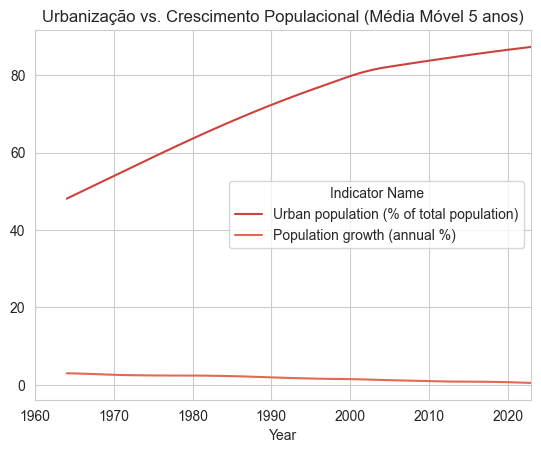

In [146]:
# Tendência de urbanização vs. crescimento populacional
plt.figure(figsize=(12, 6))
dados_brasil_filled[["Urban population (% of total population)", "Population growth (annual %)"]].rolling(window=5).mean().plot()
plt.title("Urbanização vs. Crescimento Populacional (Média Móvel 5 anos)")
plt.show()

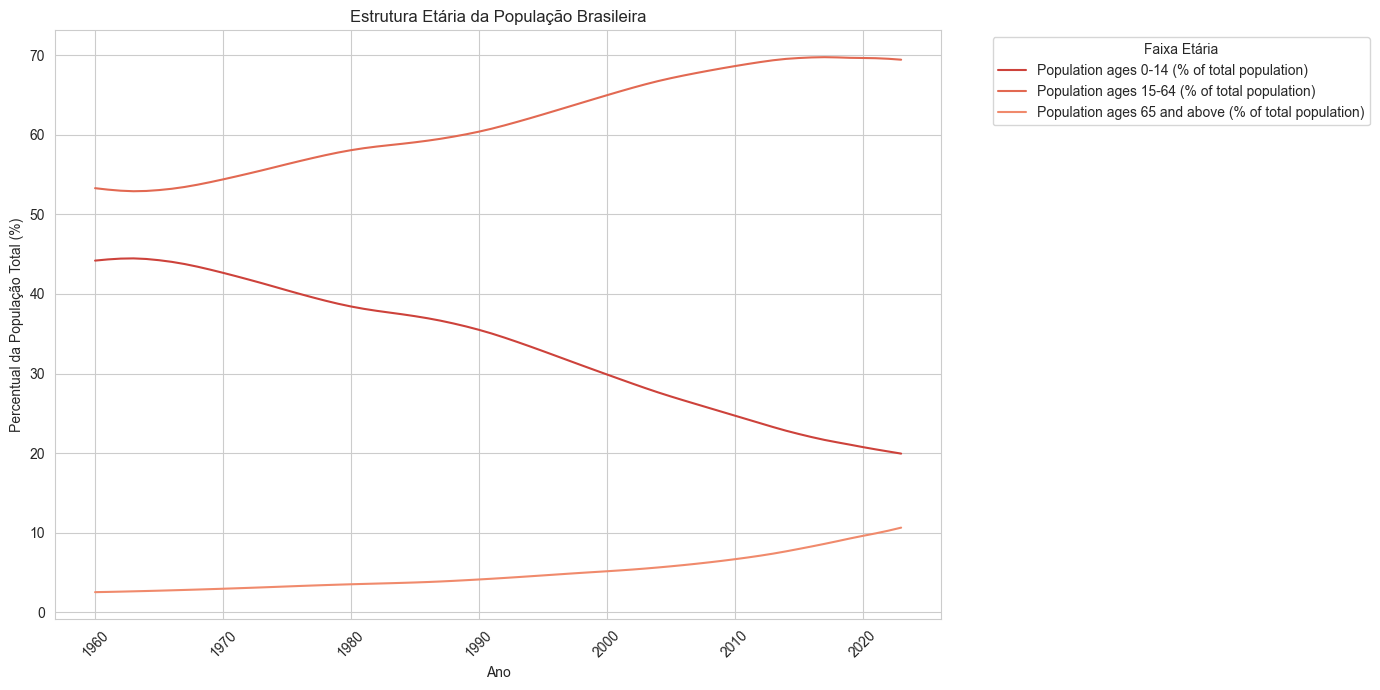

In [147]:
# Análise da estrutura etária ao longo do tempo
faixas_etarias = [
    'Population ages 0-14 (% of total population)',
    'Population ages 15-64 (% of total population)',
    'Population ages 65 and above (% of total population)'
]

estrutura_etaria = brasil[brasil['Indicator Name'].isin(faixas_etarias)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=estrutura_etaria, x='Year', y='Value', hue='Indicator Name')
plt.title('Estrutura Etária da População Brasileira')
plt.ylabel('Percentual da População Total (%)')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Faixa Etária', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [148]:
fertilidade = brasil[brasil['Indicator Name'] == 'Fertility rate, total (births per woman)'][['Year', 'Value']].rename(columns={'Value': 'Fertility Rate'})
populacao_total = brasil[brasil['Indicator Name'] == 'Population, total'][['Year', 'Value']].rename(columns={'Value': 'Population Total'})
urbanizacao = brasil[brasil['Indicator Name'] == 'Urban population (% of total population)'][['Year', 'Value']].rename(columns={'Value': 'Urbanization (%)'})


df_plot = populacao_total.merge(fertilidade, on='Year').merge(urbanizacao, on='Year')


fig = px.scatter(
    df_plot,
    x='Population Total',
    y='Fertility Rate',
    size='Urbanization (%)',  # Tamanho dos pontos baseado no percentual de urbanização
    color='Urbanization (%)',  # Cor dos pontos baseado no percentual de urbanização
    hover_data=['Year'],  # Mostrar o ano ao passar o mouse
    title='Relação entre Fertilidade, População Total e Urbanização (Brasil)',
    labels={'Fertility Rate': 'Taxa de Fertilidade', 'Population Total': 'População Total', 'Urbanization (%)': 'Urbanização (%)'}
)

fig.show()

Dados disponíveis para Brazil: 64 anos


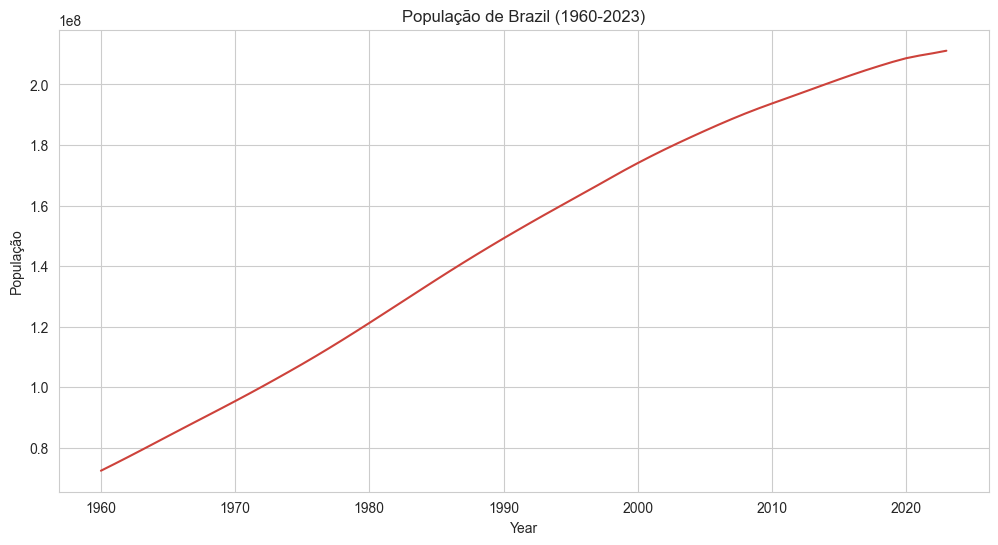

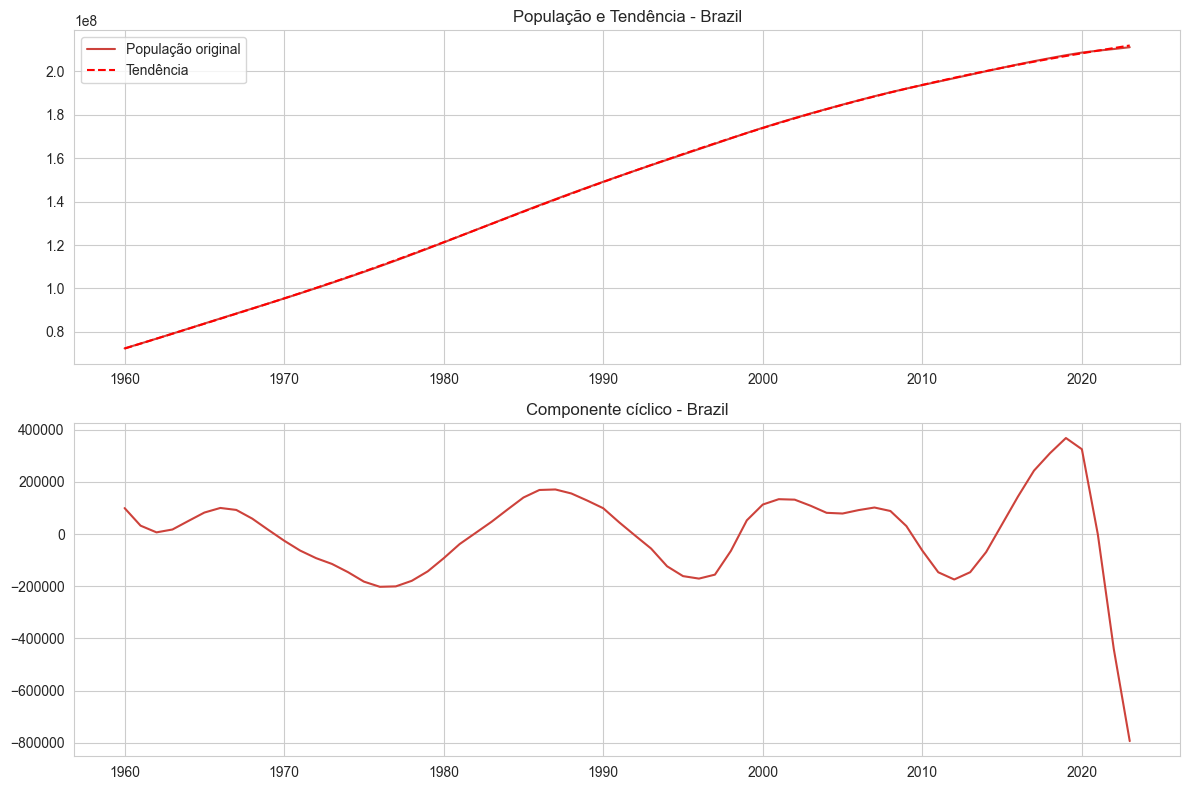

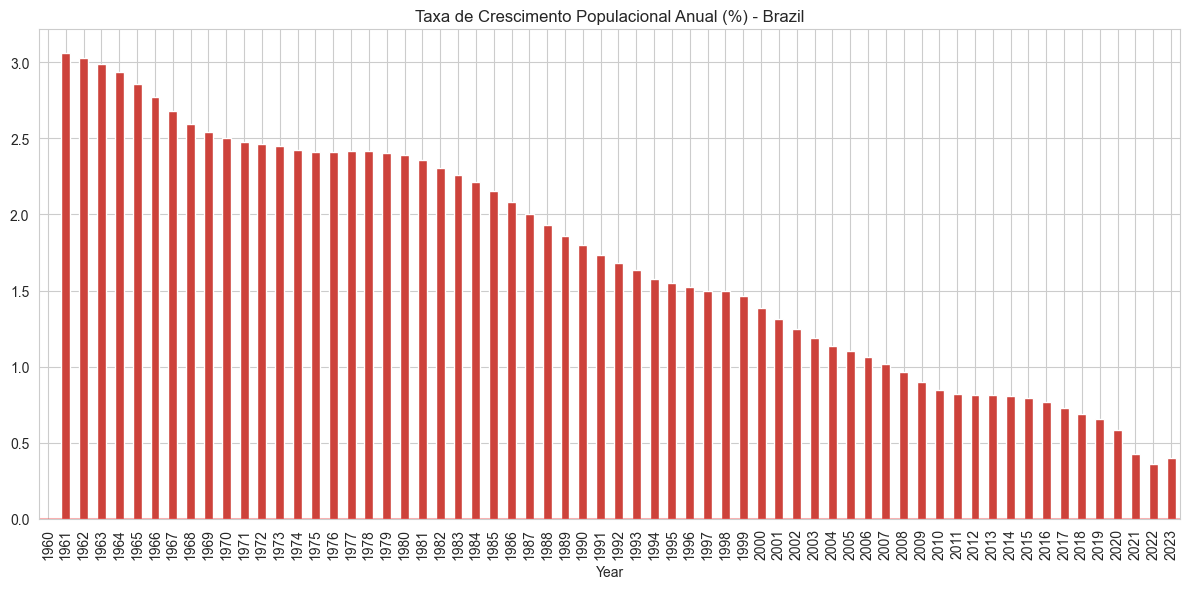

In [149]:
# Para dados anuais, podemos analisar a tendência de crescimento populacional
# Primeiro, vamos garantir que os dados estão na estrutura correta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter
import statsmodels.api as sm

# Suponha que temos uma série temporal de população por país
# Selecionar dados de população para um país específico
pais = "Brazil"  # ou qualquer outro país de interesse
dados_pop = dados_filtrados[(dados_filtrados["Country Name"] == pais) & 
                          (dados_filtrados["Indicator Name"] == "Population, total")]

# Criar uma série temporal adequada
pop_ts = dados_pop.set_index("Year")["Value"]

# Verificar se temos dados suficientes
print(f"Dados disponíveis para {pais}: {len(pop_ts)} anos")

# Visualizar a série temporal básica
plt.figure(figsize=(12, 6))
pop_ts.plot()
plt.title(f"População de {pais} (1960-2023)")
plt.ylabel("População")
plt.grid(True)
plt.show()

# Analisar a tendência usando o filtro Hodrick-Prescott
if len(pop_ts) > 5:  # Verificar se há dados suficientes
    ciclo, tendencia = hpfilter(pop_ts, lamb=100)  # lambda=100 para dados anuais
    
    plt.figure(figsize=(12, 8))
    plt.subplot(211)
    plt.plot(pop_ts, label="População original")
    plt.plot(tendencia, 'r--', label="Tendência")
    plt.legend()
    plt.title(f"População e Tendência - {pais}")
    plt.grid(True)
    
    plt.subplot(212)
    plt.plot(ciclo, label="Ciclo (flutuações)")
    plt.title(f"Componente cíclico - {pais}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Calcular taxa de crescimento anual
    taxa_crescimento = pop_ts.pct_change() * 100
    
    plt.figure(figsize=(12, 6))
    taxa_crescimento.plot(kind='bar')
    plt.title(f"Taxa de Crescimento Populacional Anual (%) - {pais}")
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

#### Urbanizão x economia

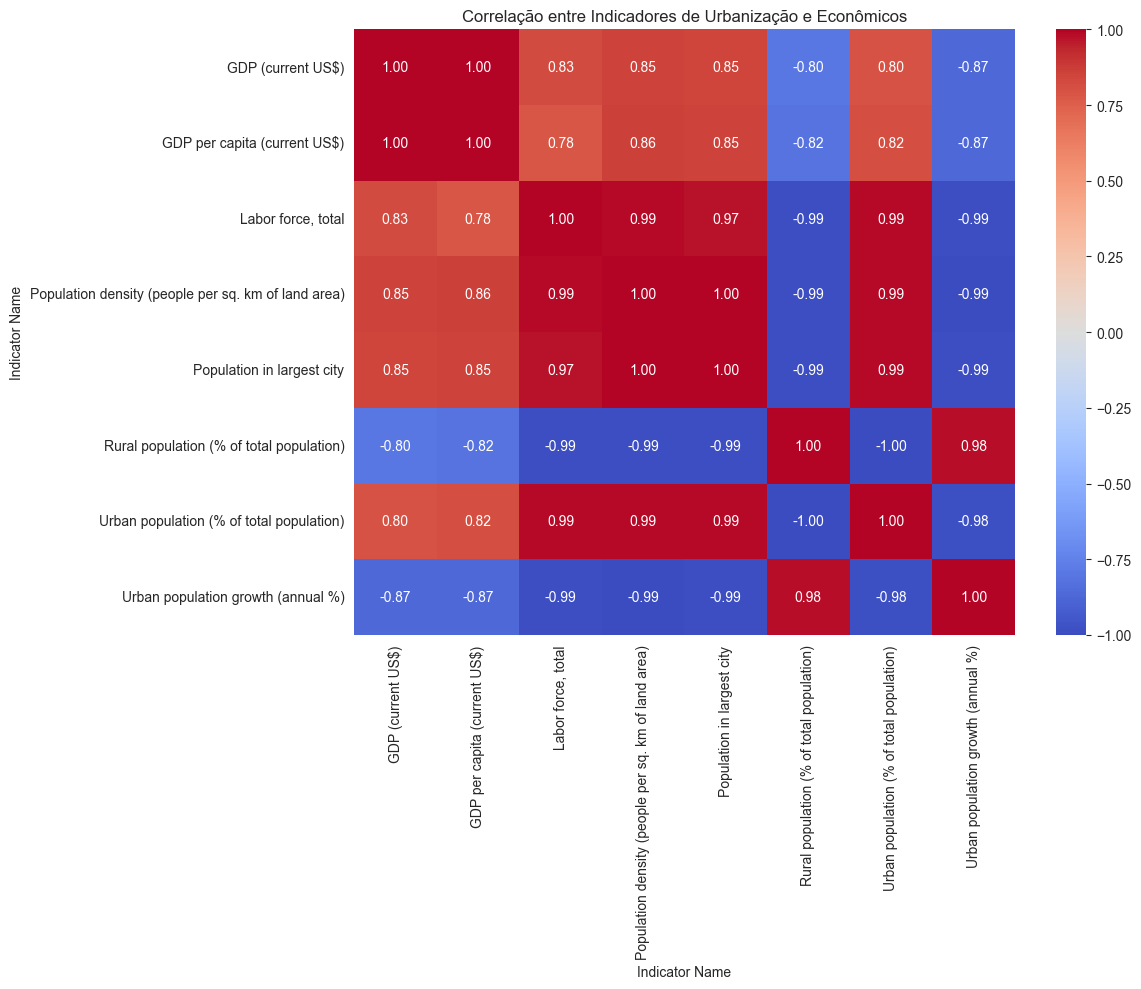

In [150]:

# Análise de correlação entre fatores de urbanização e econômicos
indicadores_correlacao = [
        ## Econômicos:
    "GDP per capita (current US$)",
    "Unemployment, total (% of total labor force)",
    "GDP (current US$)",
    "Labor force, total",

    ## Urbanização:
    "Urban population (% of total population)",
    "Urban population growth (annual %)",
    "Population in largest city",
    "Urban land area (% of total land area)",
    "Population density (people per sq. km of land area)",
    "Rural population (% of total population)"
]

# Filtrar apenas os indicadores selecionados
dados_corr = brasil[brasil['Indicator Name'].isin(indicadores_correlacao)]

# Pivotar para formato amplo
dados_corr_wide = dados_corr.pivot(index='Year', columns='Indicator Name', values='Value')

# Calcular correlação
matriz_corr = dados_corr_wide.corr()

# Plotar mapa de calor de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlação entre Indicadores de Urbanização e Econômicos')
plt.tight_layout()
plt.show()

## Comparação com outros países

In [151]:
# Lista de países para comparação
paises_comparacao = ["Brazil", "Russian Federation", "India", "China", "South Africa",  # BRICS
                     "Argentina", "Mexico", "Colombia","United States", "Canada" #America
                     "Germany", "France", "Italy", "Spain", "United Kingdom"] # Europa]  

# Filtrar dados apenas para esses países
dados_comparacao = dados_long[dados_long["Country Name"].isin(paises_comparacao)]
dados_comparacao = dados_comparacao[dados_comparacao["Indicator Name"].isin(indicadores_interesse)]

# Criar subconjuntos para cada país
sub_dfs_paises_comparacao = {pais: grupo for pais, grupo in dados_comparacao.groupby("Country Name")}

# Criar dataframes pivotados para cada país
dfs_wide_por_pais = {}
for pais in sub_dfs_paises_comparacao:
    df_temp = sub_dfs_paises_comparacao[pais][["Year", "Indicator Name", "Value"]].copy()
    dfs_wide_por_pais[pais] = df_temp.pivot(
        index="Year",
        columns="Indicator Name",
        values="Value"
    )
    dfs_wide_por_pais[pais].sort_index(inplace=True)

In [152]:
import plotly.express as px

# Filtrar os dados de crescimento populacional
dados_crescimento = dados_comparacao[dados_comparacao['Indicator Name'] == 'Population growth (annual %)']
dados_crescimento = dados_crescimento.sort_values(by='Year')

# Definir os ticks do eixo X com espaçamento adequado
anos_min = int(dados_crescimento["Year"].min())
anos_max = int(dados_crescimento["Year"].max())
tick_spacing = 5 if (anos_max - anos_min) > 10 else 1
tick_vals = list(range(anos_min, anos_max + 1, tick_spacing))

# Criar gráfico de linhas com marcadores e cores distintas usando a paleta Set1
fig = px.line(
    dados_crescimento,
    x='Year',
    y='Value',
    color='Country Name',
    markers=True,
    title='Comparação da Taxa de Crescimento Populacional entre Países',
    color_discrete_sequence=px.colors.qualitative.Set1  # Paleta com cores bem diferentes
)

# Atualizar os ticks do eixo X com rotação de 45° e valores definidos
fig.update_xaxes(
    tickangle=45,
    tickmode='array',
    tickvals=tick_vals,
    title="Ano"
)

# Atualizar o rótulo do eixo Y
fig.update_yaxes(title="Crescimento Anual (%)")

# Atualizar o layout do gráfico para um visual limpo e dimensionamento adequado
fig.update_layout(
    template='plotly_white',
    xaxis_title='Ano',
    yaxis_title='Crescimento Anual (%)',
    legend_title_text='País',
    width=1400,
    height=800,
    margin=dict(l=50, r=150, t=80, b=50)
)

fig.show()



In [153]:
import plotly.express as px

# Definição dos grupos de países
grupos_paises = {
    "BRICS": ["Brazil", "Russian Federation", "India", "China", "South Africa"],
    "América": ["Brazil", "Argentina", "Mexico", "Colombia", "United States", "Canada"],
    "Europa": ["Germany", "France", "Italy", "Spain", "United Kingdom"]
}

# Filtrar os dados para o indicador "Population growth (annual %)"
dados_crescimento = dados_comparacao[dados_comparacao["Indicator Name"] == "Population growth (annual %)"]
dados_crescimento = dados_crescimento.sort_values(by="Year")

# Gerar um gráfico para cada grupo de países
for grupo, paises in grupos_paises.items():
    # Filtrar os dados para o grupo atual
    dados_grupo = dados_crescimento[dados_crescimento["Country Name"].isin(paises)]
    
    # Definir os ticks do eixo X com espaçamento adequado
    anos_min = int(dados_grupo["Year"].min())
    anos_max = int(dados_grupo["Year"].max())
    tick_spacing = 5 if (anos_max - anos_min) > 10 else 1
    tick_vals = list(range(anos_min, anos_max + 1, tick_spacing))
    
    # Criar o gráfico de linhas com marcadores e cores distintas
    fig = px.line(
        dados_grupo,
        x="Year",
        y="Value",
        color="Country Name",
        markers=True,
        title=f"Taxa de Crescimento Populacional: {grupo}",
        color_discrete_sequence=px.colors.qualitative.Set1
    )
    
    # Atualizar os ticks do eixo X com rotação de 45°
    fig.update_xaxes(
        tickangle=45,
        tickmode="array",
        tickvals=tick_vals,
        title="Ano"
    )
    
    # Atualizar o rótulo do eixo Y
    fig.update_yaxes(title="Crescimento Anual (%)")
    
    # Atualizar o layout para um visual limpo e dimensionamento adequado
    fig.update_layout(
        template="plotly_white",
        xaxis_title="Ano",
        yaxis_title="Crescimento Anual (%)",
        legend_title_text="País",
        width=1400,
        height=800,
        margin=dict(l=50, r=150, t=80, b=50)
    )
    
    fig.show()



Text(0.5, 1.0, 'Distribuição da População Adulta (15-64 anos) por País')

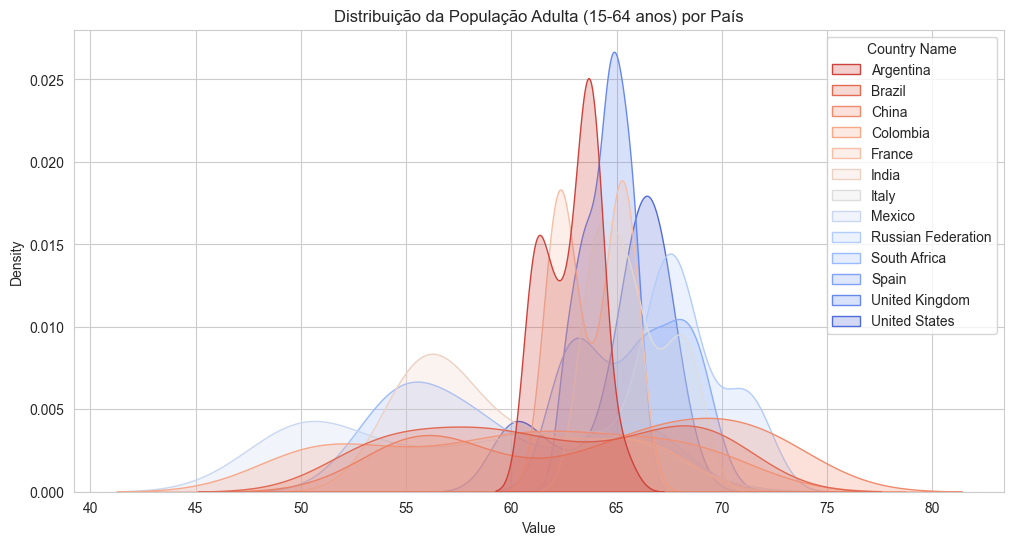

In [154]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=dados_comparacao[dados_comparacao['Indicator Name'] == 'Population ages 15-64 (% of total population)'], 
            x='Value', hue='Country Name', fill=True)
plt.title('Distribuição da População Adulta (15-64 anos) por País')

Text(0.5, 1.0, 'Percentual de População Adulta por País')

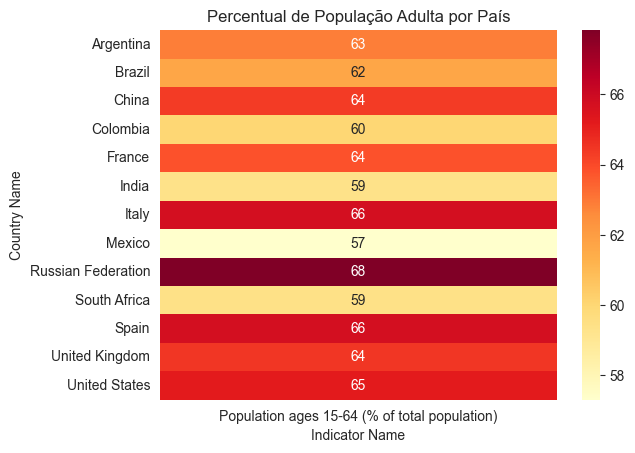

In [155]:
pivot_table = dados_comparacao.pivot_table(index='Country Name', columns='Indicator Name', values='Value')
sns.heatmap(pivot_table[['Population ages 15-64 (% of total population)']], annot=True, cmap='YlOrRd')
plt.title('Percentual de População Adulta por País')